# Door Orientation Inference Viewer
Batch inference on a folder of crop images using ArcDetectorCNN.

/!\ To match the conditions in which the CNN was trained, any input image should be:
- square
- door sill at the bottom (ie door opening upwards)

## Config

In [48]:
from pathlib import Path

# Path to a single image OR a folder of images
INPUT_PATH = Path("./never_seen")

# Model weights
MODEL_PATH = Path("door_orientation_model.pt") # supposedly the highest-performing model

# Confidence threshold — predictions below this show as 'unknown'
THRESHOLD = 0.4

# Max images to display (None = all)
MAX_DISPLAY = 64

# Grid columns
COLS = 8

## Load model

In [49]:
import torch
import cv2
from door_orientation_inference import load_orientation_model, _crop_to_tensor, _HINGE_PLACEMENT_NAMES, _DEVICE

model = load_orientation_model(MODEL_PATH)
model.eval()
print(f"Device: {_DEVICE}")

ALL_LABELS = [*_HINGE_PLACEMENT_NAMES, "no_door"]
ALL_LABELS

2026-03-18 16:36:36.405 | SUCCESS  | door_orientation_inference:load_orientation_model:86 - Loaded door orientation model from door_orientation_model.pt with config: {'n_blocks': 4, 'dropout': 0.5, 'best_val_acc': 0.8914027149321267, 'num_classes': 4} in memory


Device: mps


['double', 'hinge_left', 'hinge_right', 'no_door']

## Collect images

In [50]:
if INPUT_PATH.is_dir():
    image_paths = sorted(INPUT_PATH.glob("*.png")) + sorted(INPUT_PATH.glob("*.jpg"))
else:
    image_paths = [INPUT_PATH]

if MAX_DISPLAY is not None:
    image_paths = image_paths[:MAX_DISPLAY]

print(f"{len(image_paths)} images found")

13 images found


## Run inference

In [51]:
import numpy as np


def _center_crop_square(img_rgb: np.ndarray) -> np.ndarray:
    """Center-crop to the largest square contained in the image."""
    h, w = img_rgb.shape[:2]
    s = min(h, w)
    y0 = (h - s) // 2
    x0 = (w - s) // 2
    return img_rgb[y0 : y0 + s, x0 : x0 + s]


results = []  # list of (path, img_rgb, label, confidence, probs)

with torch.no_grad():
    for p in image_paths:
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            print(f"Could not read {p} — skipping")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = _center_crop_square(img_rgb)
        tensor = _crop_to_tensor(img_rgb).to(_DEVICE)
        probs = model(tensor).softmax(dim=1)[0].cpu()
        conf, idx = probs.max(dim=0)
        conf = conf.item()
        label = ALL_LABELS[idx.item()] if conf >= THRESHOLD else "unknown"
        results.append((p, img_rgb, label, conf, probs))

print(f"Inference done on {len(results)} images")

Inference done on 13 images


## Display results

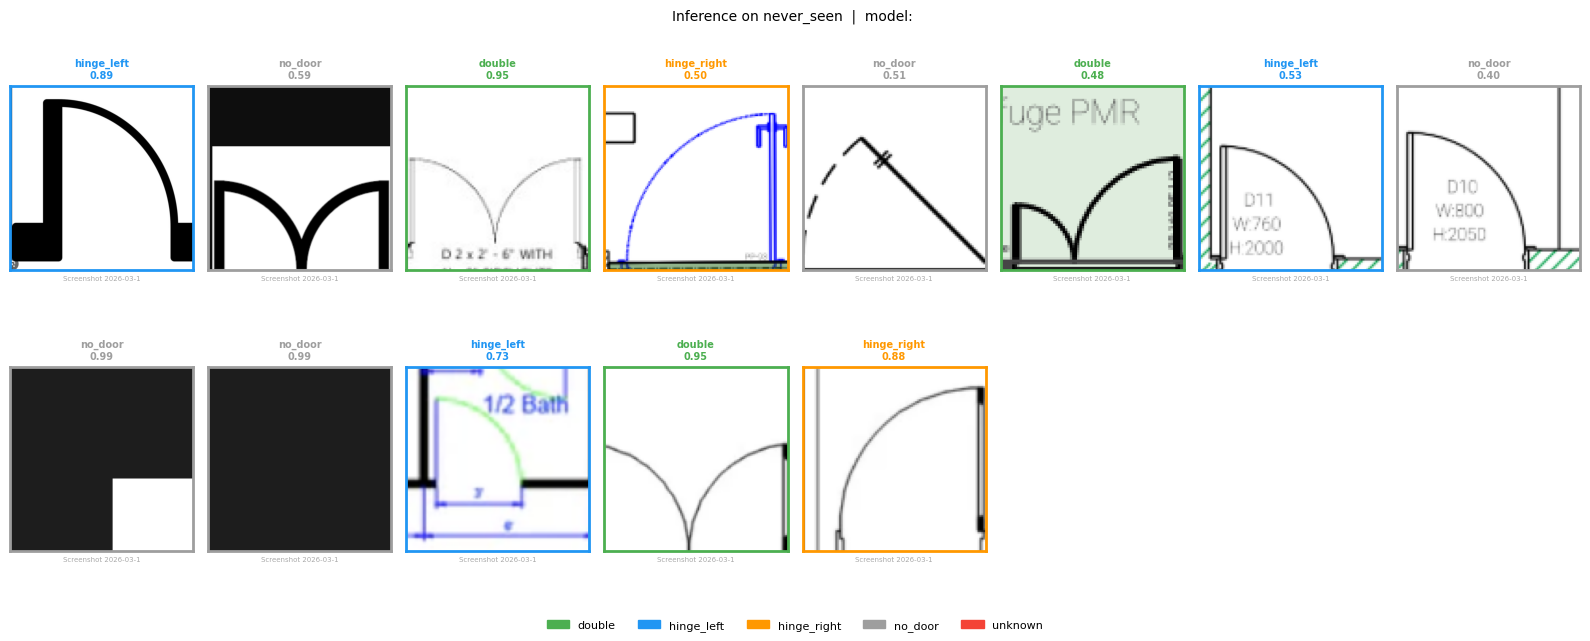

In [52]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

LABEL_COLORS = {
    "double":      "#4CAF50",
    "hinge_left":  "#2196F3",
    "hinge_right": "#FF9800",
    "no_door":      "#9E9E9E",
    "unknown":     "#F44336",
}

rows = math.ceil(len(results) / COLS)
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 2, rows * 3.2))
axes = np.array(axes).reshape(-1)  # flatten for easy indexing

for ax, (path, img_rgb, label, conf, probs) in zip(axes, results):
    ax.imshow(img_rgb)
    color = LABEL_COLORS.get(label, "white")
    ax.set_title(f"{label}\n{conf:.2f}", fontsize=7, color=color, fontweight="bold")
    ax.set_xlabel(path.stem[:20], fontsize=5, color="#aaaaaa")
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

# Hide unused axes
for ax in axes[len(results):]:
    ax.set_visible(False)

legend = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
fig.legend(handles=legend, loc="lower center", ncol=len(LABEL_COLORS), fontsize=8, frameon=False)
fig.suptitle(f"Inference on {INPUT_PATH}  |  model: {MODEL_PATH.parent.name}", fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1], h_pad=3.0)
plt.show()

## Per-label probability breakdown (for a single image)

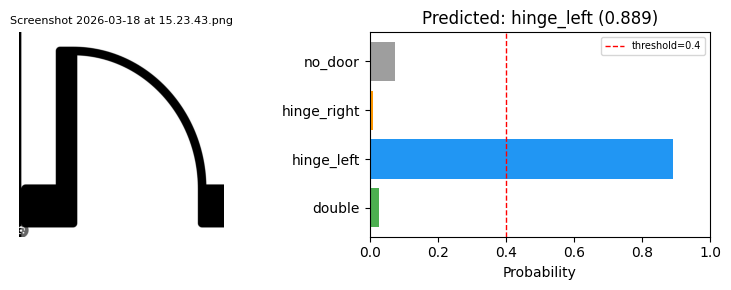

In [54]:
# Change index to inspect a different image
INSPECT_IDX = 0

path, img_rgb, label, conf, probs = results[INSPECT_IDX]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(8, 3))

ax_img.imshow(img_rgb)
ax_img.set_title(path.name, fontsize=8)
ax_img.axis("off")

colors = [LABEL_COLORS.get(l, "gray") for l in ALL_LABELS[:len(probs)]]
ax_bar.barh(ALL_LABELS[:len(probs)], probs.numpy(), color=colors)
ax_bar.set_xlim(0, 1)
ax_bar.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"threshold={THRESHOLD}")
ax_bar.set_xlabel("Probability")
ax_bar.set_title(f"Predicted: {label} ({conf:.3f})")
ax_bar.legend(fontsize=7)

plt.tight_layout()
plt.show()

## View full, never seen floorplans

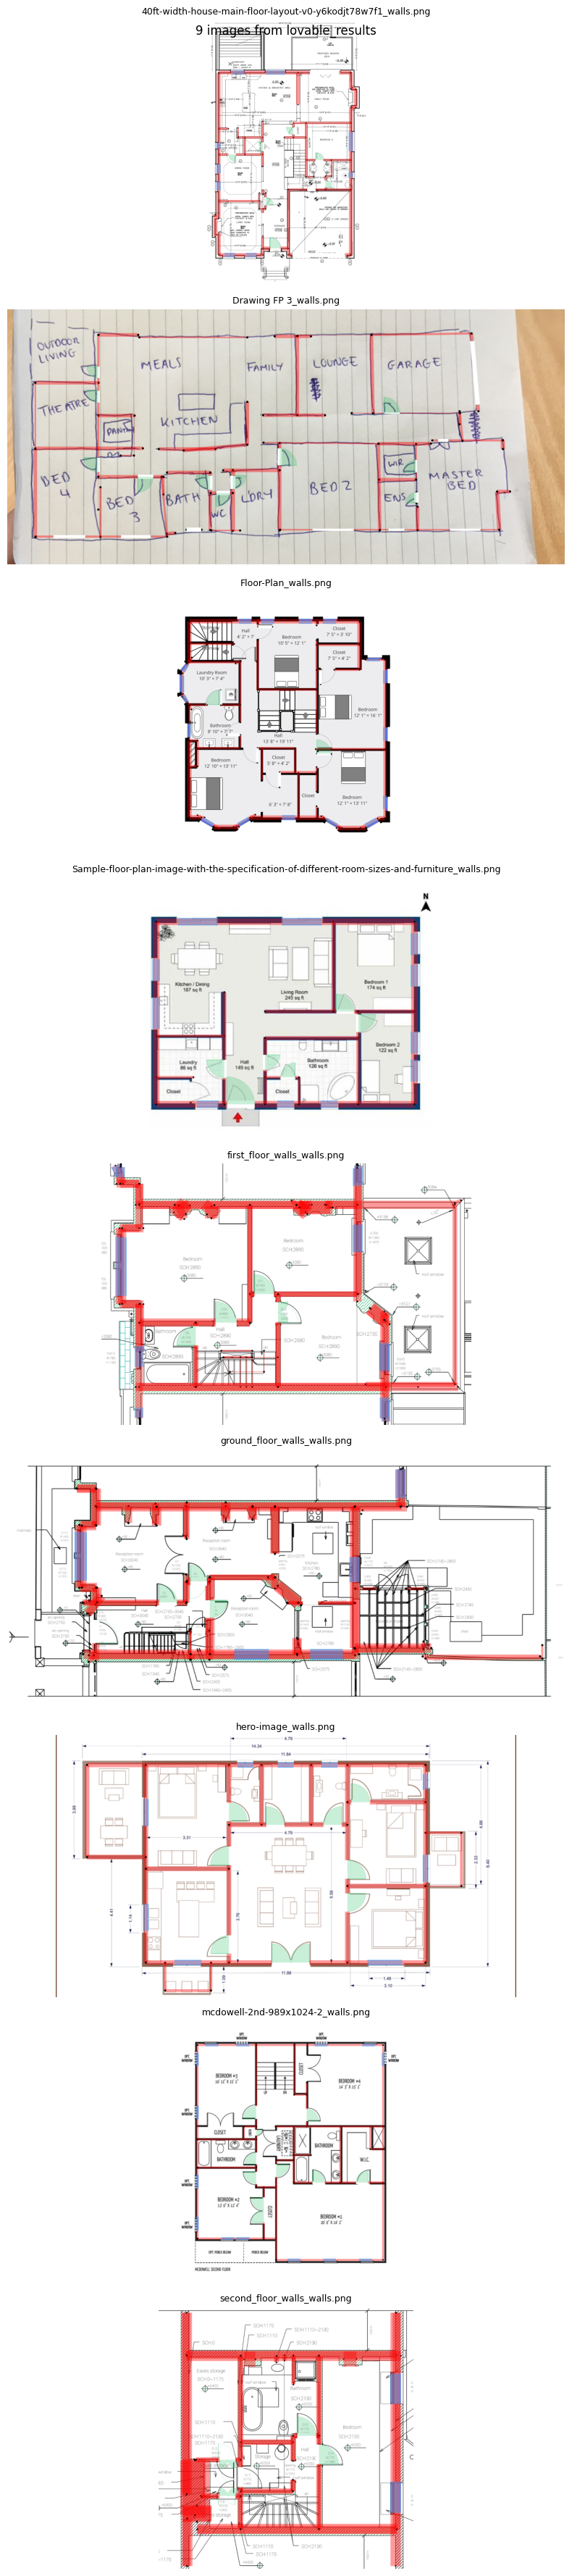

In [ ]:
# Display all images from ./lovable_results in a grid (1 per row, near native resolution)

from pathlib import Path
import cv2
import matplotlib.pyplot as plt

FLOORPLANS_DIR = Path("./lovable_results")
FLOORPLAN_EXTS = ("*.png", "*.jpg", "*.jpeg", "*.webp")
DISPLAY_DPI = 100
SCALE = 1.0  # 1.0 ~= natural pixel size; increase (e.g. 1.2) to enlarge further

full_paths = []
for ext in FLOORPLAN_EXTS:
    full_paths.extend(sorted(FLOORPLANS_DIR.glob(ext)))

if not full_paths:
    print(f"No images found in {FLOORPLANS_DIR.resolve()}")
else:
    loaded = []  # (path, rgb, height, width)
    for p in full_paths:
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            print(f"Unreadable: {p.name}")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        loaded.append((p, img_rgb, h, w))

    if not loaded:
        print("No readable images found.")
    else:
        width_px = max(w for _, _, _, w in loaded)
        height_ratios = [h for _, _, h, _ in loaded]
        total_height_px = sum(height_ratios)

        fig, axes = plt.subplots(
            nrows=len(loaded),
            ncols=1,
            figsize=(SCALE * width_px / DISPLAY_DPI, SCALE * total_height_px / DISPLAY_DPI),
            dpi=DISPLAY_DPI,
            gridspec_kw={"height_ratios": height_ratios},
        )

        if len(loaded) == 1:
            axes = [axes]
        else:
            axes = list(axes)

        for ax, (p, img_rgb, _, _) in zip(axes, loaded):
            ax.imshow(img_rgb, interpolation="nearest")
            ax.set_title(p.name, fontsize=9)
            ax.axis("off")

        fig.suptitle(f"{len(loaded)} images from {FLOORPLANS_DIR}", fontsize=12)
        plt.tight_layout()
        plt.show()